In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import numpy as np

np.random.seed(42)

IMG_SIZE = 28
SAMPLES = 200

X = []
y = []

# Create 5 different artificial patterns
for label in range(5):

    for i in range(SAMPLES):

        image = np.zeros((IMG_SIZE, IMG_SIZE))

        # Palm
        if label == 0:
            image[5:23, 10:18] = 1
            image[3:10, 8:11] = 1
            image[3:10, 17:20] = 1

        # Fist
        elif label == 1:
            image[9:20, 7:21] = 1
            image[6:10, 9:19] = 1

        # Thumb
        elif label == 2:
            image[10:23, 10:18] = 1
            image[5:12, 15:21] = 1

        # L gesture
        elif label == 3:
            image[5:22, 7:11] = 1
            image[19:23, 7:20] = 1

        # Peace gesture
        elif label == 4:
            image[5:18, 7:11] = 1
            image[5:18, 17:21] = 1
            image[15:23, 9:19] = 1

        # Add small random noise
        noise = np.random.normal(0, 0.1, (IMG_SIZE, IMG_SIZE))

        image = image + noise

        X.append(image)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (1000, 28, 28)
Labels: (1000,)


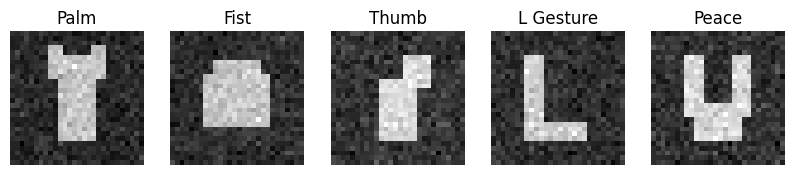

In [3]:
gesture_names = [
    "Palm",
    "Fist",
    "Thumb",
    "L Gesture",
    "Peace"
]

plt.figure(figsize=(10, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X[i * SAMPLES], cmap="gray")
    plt.title(gesture_names[i])
    plt.axis("off")

plt.show()

In [4]:
X = X.reshape(X.shape[0], -1)

print("New shape:", X.shape)

New shape: (1000, 784)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 784)
Testing data: (200, 784)


In [6]:
model = SVC(kernel="linear")

print("SVM model created")

SVM model created


In [8]:
model.fit(X_train, y_train)

print("Training completed!")

Training completed!


In [9]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[2 3 3 3 2 3 3 2 4 0 4 0 3 4 4 4 1 4 3 1]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy percentage: 100.0 %


In [11]:
print(classification_report(
    y_test,
    y_pred,
    target_names=gesture_names
))

              precision    recall  f1-score   support

        Palm       1.00      1.00      1.00        33
        Fist       1.00      1.00      1.00        48
       Thumb       1.00      1.00      1.00        37
   L Gesture       1.00      1.00      1.00        38
       Peace       1.00      1.00      1.00        44

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [12]:
index = 10

prediction = model.predict([X_test[index]])

print("Predicted Gesture:", gesture_names[prediction[0]])
print("Actual Gesture:", gesture_names[y_test[index]])

Predicted Gesture: Peace
Actual Gesture: Peace


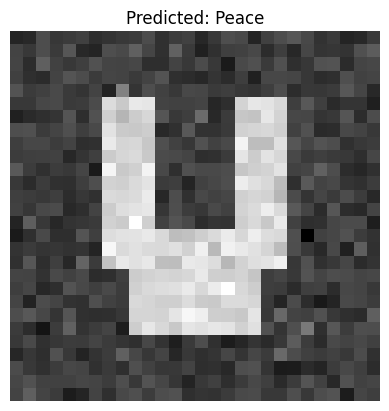

In [13]:
plt.imshow(X_test[index].reshape(28, 28), cmap="gray")

plt.title(
    "Predicted: " + gesture_names[prediction[0]]
)

plt.axis("off")
plt.show()